## Syntetic Control

In [67]:
import polars as pl
import numpy as np
import pandas as pd

### Online Marketing Dataset

In [68]:
df = (
    pl.read_csv("../data/online_mkt.csv")
      .with_columns(
        pl.col("date").str.to_date()
      )
)
df

app_download,population,city,state,date,post,treated
f64,i64,str,str,date,i64,i64
3066.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-01,0,1
2701.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-02,0,1
1927.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-03,0,1
1451.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-04,0,1
1248.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-05,0,1
…,…,…,…,…,…,…
99.0,481725,"""maua""","""sao_paulo""",2022-06-26,1,0
233.0,481725,"""maua""","""sao_paulo""",2022-06-27,1,0
241.0,481725,"""maua""","""sao_paulo""",2022-06-28,1,0


In [69]:
treated = df.filter(pl.col("treated") == 1).select("city").unique()
treated = treated.to_series().to_list()
treated

['sao_paulo', 'porto_alegre', 'joao_pessoa']

Puede ser complejo manejar a ciudades enormes como por ejemplo **Sao Paolo** que tiene una catidad enorme de habitantes
ya que como es de las más grandes del mundo, con más habitantes, asemejarse a la misma es complejo.

In [70]:
df_norm = df.with_columns(
    app_download_pct = (pl.col("app_download") / pl.col("population")) * 100
)
df_norm

app_download,population,city,state,date,post,treated,app_download_pct
f64,i64,str,str,date,i64,i64,f64
3066.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-01,0,1,0.024733
2701.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-02,0,1,0.021789
1927.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-03,0,1,0.015545
1451.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-04,0,1,0.011705
1248.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-05,0,1,0.010067
…,…,…,…,…,…,…,…
99.0,481725,"""maua""","""sao_paulo""",2022-06-26,1,0,0.020551
233.0,481725,"""maua""","""sao_paulo""",2022-06-27,1,0,0.048368
241.0,481725,"""maua""","""sao_paulo""",2022-06-28,1,0,0.050029


Nos damos cuenta de que el tratamiento en las ciudades comenzo en 2022-05-01

In [71]:
tr_period = df_norm.filter(pl.col("post") == 1).select(pl.col("date").min()).item()
tr_period

datetime.date(2022, 5, 1)

## 1. Las Variables Principales

- **$D_i$ (Tratamiento):** Indica si una unidad $i$ (ciudad, estado, empresa) pertenece al grupo que recibirá el tratamiento. Es una variable fija para esa unidad:  
    Si, por ejemplo, California es tratada, entonces $D_{\text{California}} = 1$ siempre.

- **$t$ (Tiempo):** Es el reloj del experimento, es decir, el índice temporal (días, meses, años).

- **$T$ (Total):** El número total de periodos que tienes en tus datos.

---

## 2. La Línea de Tiempo del Experimento

El tiempo se divide en dos bloques críticos:

- **$T_{pre}$:** El periodo de "entrenamiento" o pre-intervención. Aquí es donde el Control Sintético intenta copiar el comportamiento de la unidad tratada.
- **$T_{post}$:** El periodo después de la intervención, donde medimos el impacto.

**Momento del impacto:**  
El tratamiento ocurre formalmente solo cuando se cumplen dos condiciones:  
- La unidad es del grupo tratado ($D=1$)
- El tiempo es posterior a la intervención ($t > T_{pre}$)

---

## 3. La Variable de Interacción ($W_{it}$)

Esta es la variable que realmente "enciende" el efecto en los modelos:

$$
W_{it} = D_i \times Post_t
$$

- Si estás en el pasado ($t < T_{pre}$), $Post_t = 0$, por lo que $W_{it} = 0$.
- Si eres una unidad de control ($D=0$), $W_{it}$ siempre es 0.
- $W_{it} = 1$ **solo** para la unidad tratada durante el periodo de impacto.


Ciudades encontradas: ['porto_alegre', 'joao_pessoa', 'sao_paulo']


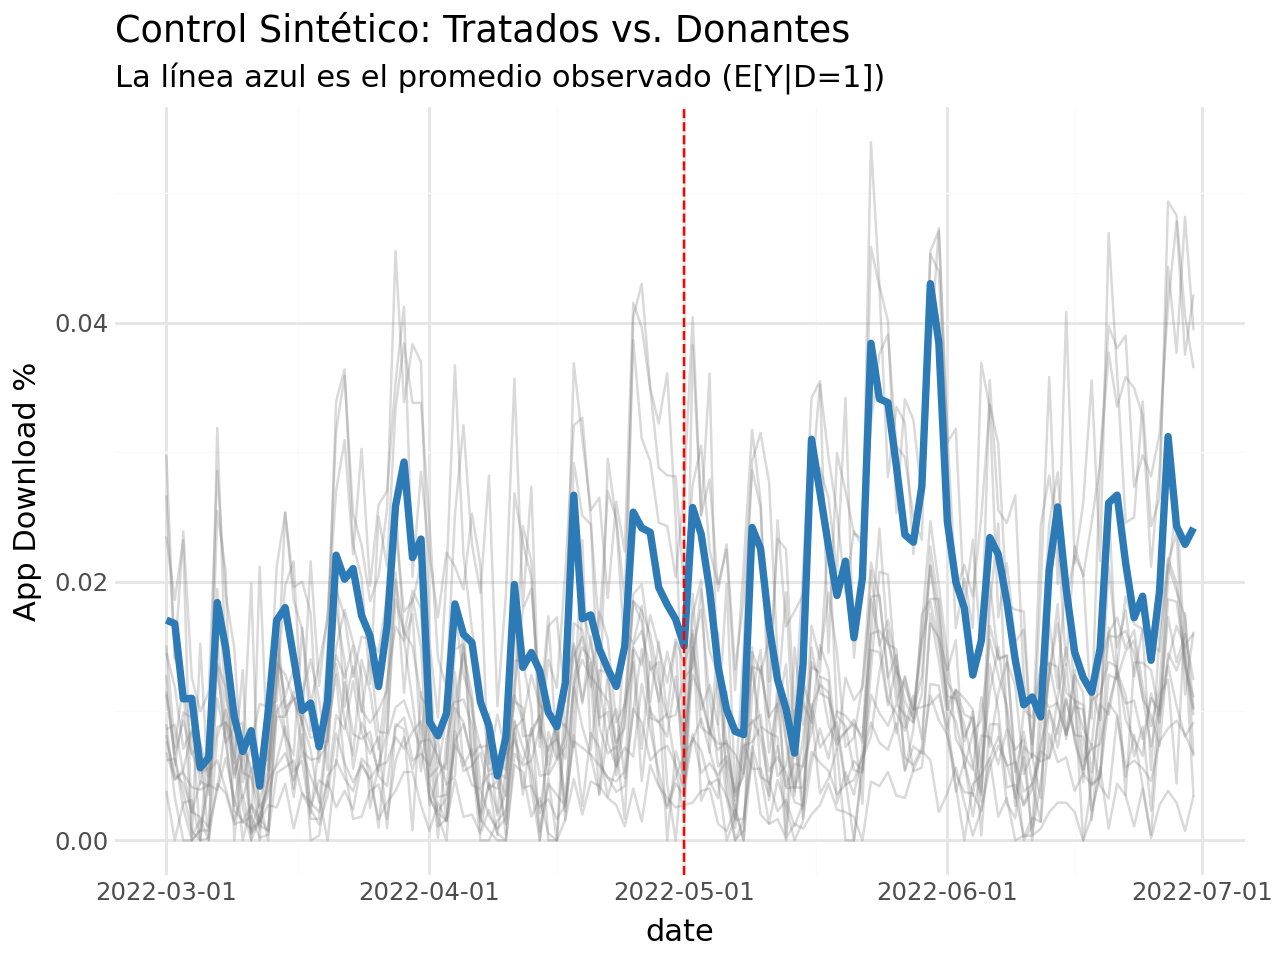

In [72]:

from plotnine import *
import random


treated_clean = treated

# 1. Preparar DataFrame (Pivot)
df_sc = (
    df_norm
    .with_columns(pl.col("city").cast(pl.String).str.to_lowercase().str.strip_chars())
    .pivot(values="app_download_pct", index="date", on="city")
    .sort("date")
)

# 2. Intersección (Ahora sí funcionará porque son strings puros)
treated_cols = list(set(df_sc.columns) & set(treated_clean))

# Verificación visual
print(f"Ciudades encontradas: {treated_cols}")

# 3. Preparar datos para el gráfico
# A: Promedio Tratados
df_mean = df_sc.select(pl.col("date"), pl.mean_horizontal(treated_cols).alias("value"))

# B: Controles (Donantes)
control_cols = list(set(df_sc.columns) - set(treated_cols) - {"date"})
sample_n = min(len(control_cols), 15)

random.seed(123)
df_bg = df_sc.select("date", *random.sample(control_cols, sample_n)).unpivot(
    index="date", variable_name="city", value_name="value"
)

# 4. Gráfico
(
    ggplot()
    + geom_line(df_bg, aes("date", "value", group="city"), color="gray", alpha=0.3)
    + geom_line(df_mean, aes("date", "value"), color="#2c7bb6", size=1.5)
    + geom_vline(xintercept=pd.to_datetime(tr_period), linetype="dashed", color="red")
    + labs(
        title="Control Sintético: Tratados vs. Donantes",
        subtitle="La línea azul es el promedio observado (E[Y|D=1])",
        y="App Download %"
    )
    + theme_minimal()
)

## Matrix Representation

El syntetic control se puede representar como una matriz donde las filas son las unidades (ciudades) y las columnas son los periodos de tiempo. En esta matriz, el tratamiento se refleja en la columna correspondiente al periodo post-intervención para la unidad tratada.

con la siguiente fórmula de matriz (usando notación matemática para mayor claridad):

$$
W = 
\begin{bmatrix}
0_{\text{pre, co}} & 0_{\text{pre, tr}} \\
0_{\text{post, co}} & 1_{\text{post, tr}}
\end{bmatrix}
$$

Esta matriz de asignación genera la siguiente matriz de resultados potenciales observados:

$$
Y = 
\begin{bmatrix}
Y^{0}_{\text{pre, co}} & Y^{0}_{\text{pre, tr}} \\
Y^{0}_{\text{post, co}} & Y^{1}_{\text{post, tr}}
\end{bmatrix}
$$

In [73]:
import polars as pl

def reshape_sc_data(df: pl.DataFrame, 
                    geo_col: str, 
                    time_col: str, 
                    y_col: str, 
                    tr_geos: list[str], 
                    tr_start_st: str):
    
    # 1. Pivotar y Ordenar
    df_pivot = (
        df.pivot(values=y_col, index=time_col, on=geo_col)
        .sort(time_col)
    )

    # 2. Filtrar fechas
    # Convertimos el string a fecha para comparar correctamente
    cutoff_date = pl.lit(tr_start_st).str.to_date()
    
    df_pre = df_pivot.filter(pl.col(time_col) < cutoff_date)
    df_post = df_pivot.filter(pl.col(time_col) >= cutoff_date)

    # 3. Separar Matrices (CORRECCIÓN AQUÍ)
    
    # TRATADOS (Y1): Queremos [Fecha, Ciudad1, Ciudad2...]
    # Sumamos la lista [time_col] con la lista tr_geos
    cols_tr = [time_col] + tr_geos
    y_pre_tr = df_pre.select(cols_tr)
    y_post_tr = df_post.select(cols_tr)

    # CONTROLES (X0): Queremos [Fecha, Resto_de_ciudades...]
    # Excluimos SOLO las ciudades tratadas, así la fecha se queda
    y_pre_co = df_pre.select(pl.exclude(tr_geos))
    y_post_co = df_post.select(pl.exclude(tr_geos))

    return y_pre_co, y_pre_tr, y_post_co, y_post_tr



In [74]:
# --- Ejecución ---
treated_clean = ["porto_alegre", "joao_pessoa", "sao_paulo"]

y_pre_co, y_pre_tr, y_post_co, y_post_tr = reshape_sc_data(
    df=df_norm,  
    geo_col="city", 
    time_col="date", 
    y_col="app_download_pct", 
    tr_geos=treated_clean, 
    tr_start_st=str(tr_period)
)

# Verificamos que ahora sí tenga la fecha
print(y_pre_tr.head())

shape: (5, 4)
┌────────────┬──────────────┬─────────────┬───────────┐
│ date       ┆ porto_alegre ┆ joao_pessoa ┆ sao_paulo │
│ ---        ┆ ---          ┆ ---         ┆ ---       │
│ date       ┆ f64          ┆ f64         ┆ f64       │
╞════════════╪══════════════╪═════════════╪═══════════╡
│ 2022-03-01 ┆ 0.004288     ┆ 0.022039    ┆ 0.024733  │
│ 2022-03-02 ┆ 0.008107     ┆ 0.020344    ┆ 0.021789  │
│ 2022-03-03 ┆ 0.004891     ┆ 0.012352    ┆ 0.015545  │
│ 2022-03-04 ┆ 0.002948     ┆ 0.018285    ┆ 0.011705  │
│ 2022-03-05 ┆ 0.006767     ┆ 0.0         ┆ 0.010067  │
└────────────┴──────────────┴─────────────┴───────────┘


## Syntetic Control as Horizontal Regression

In [75]:
from sklearn.linear_model import LinearRegression

model = LinearRegression(fit_intercept=False)  # Sin intercepto para forzar la combinación convexa
model.fit(y_pre_co.drop("date").to_pandas(), y_pre_tr.drop("date").to_pandas().mean(axis=1))  # Ajustamos con el promedio de los tratados

# extract weights
weights_lr = model.coef_
weights_lr.round(3)

array([ 0.429,  0.007,  0.23 ,  0.132, -0.204,  0.158, -0.5  ,  0.089,
        0.115,  0.971,  0.094,  0.095,  0.128,  0.351, -0.11 , -0.041,
        0.102,  0.036,  0.147,  0.098, -0.066, -0.128, -0.086, -0.057,
        0.151,  0.555,  0.024,  0.088,  0.079, -0.239, -0.154,  0.032,
       -0.058, -0.058,  0.049, -0.353, -0.047, -0.65 , -0.205,  0.074,
       -0.476, -0.129, -0.014,  0.03 ,  0.106,  0.229, -0.002])

In [76]:
y_pre_tr.drop("date").to_pandas().mean(axis=1)

0     0.017020
1     0.016747
2     0.010929
3     0.010979
4     0.005611
        ...   
56    0.024138
57    0.023806
58    0.019548
59    0.018209
60    0.017070
Length: 61, dtype: float64

Teniendo los pesos se puede pasa a calcular la estimación de $Y^0_{\text{post, tr}}$ como una combinación lineal de las unidades de control:
$$
\hat{Y}^0_{\text{post, tr}} = \sum_{i \in \text{control}} w_i Y^0_{\text{post, i}}
$$

In [77]:
y0_tr_hat = y_post_co.drop("date").to_pandas().dot(weights_lr)
y0_tr_hat[:]

0     0.013356
1     0.018682
2     0.016760
3     0.014669
4     0.012445
        ...   
56    0.019992
57    0.029849
58    0.024227
59    0.028336
60    0.029129
Length: 61, dtype: float64

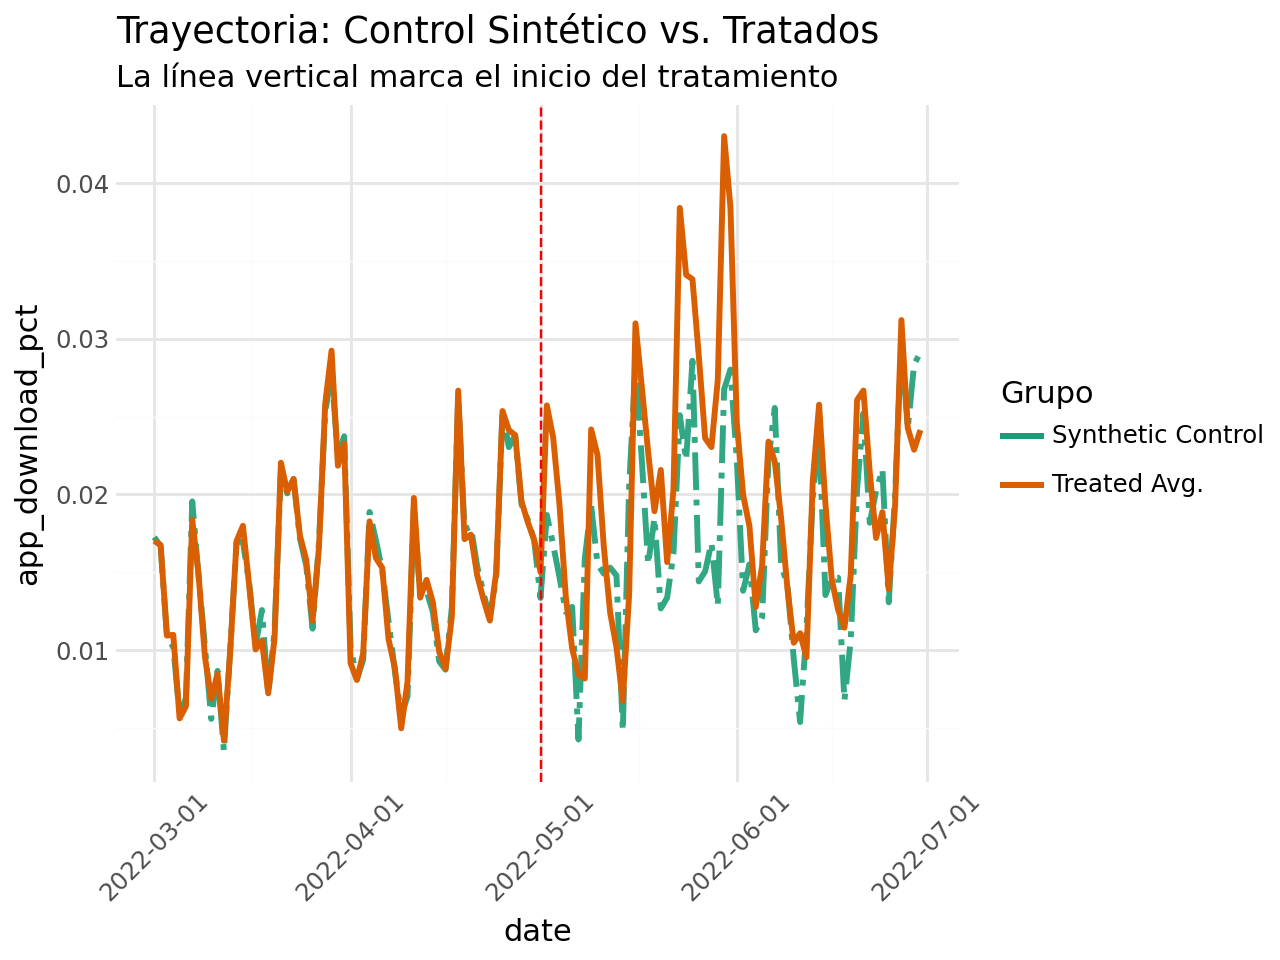

In [78]:
# 1. Concatenamos los periodos pre y post para controles y tratados
df_controls_all = pl.concat([y_pre_co, y_post_co])
df_treated_all = pl.concat([y_pre_tr, y_post_tr])

# 2. Calculamos la predicción sintética usando el modelo entrenado
synthetic = model.predict(df_controls_all.drop("date").to_pandas())

# 3. Calculamos el promedio de los tratados reales
treated_avg = df_treated_all.drop("date").to_pandas().mean(axis=1)

# 4. Armamos el DataFrame final en Polars y luego lo pasamos a pandas para plotnine
df_plot = pl.DataFrame({
    "date": df_controls_all["date"],
    "synthetic": synthetic,
    "treated_avg": treated_avg
})

# 5. Graficamos
from plotnine import *

(
    ggplot(df_plot, aes(x="date"))
    # Mapeamos el nombre del grupo al color dentro de aes() para generar la leyenda
    + geom_line(aes(y="synthetic", color="'Synthetic Control'"), linetype="dashdot", size=1.2, alpha=0.9)
    + geom_line(aes(y="treated_avg", color="'Treated Avg.'"), size=1.2)
    + geom_vline(xintercept=pd.to_datetime(tr_period), linetype="dashed", color="red")
    # Definimos los colores manualmente para cada etiqueta definida arriba
    + scale_color_manual(
        name="Grupo",
        values={"Synthetic Control": "#1b9e77", "Treated Avg.": "#d95f02"}
    )
    + labs(
        y="app_download_pct",
        title="Trayectoria: Control Sintético vs. Tratados",
        subtitle="La línea vertical marca el inicio del tratamiento"
    )
    + theme_minimal()
    + theme(axis_text_x=element_text(rotation=45))
)


In [79]:
att = y_post_tr.drop("date").to_pandas().mean() - y0_tr_hat.mean()
att

porto_alegre   -0.007725
joao_pessoa     0.001287
sao_paulo       0.015276
dtype: float64

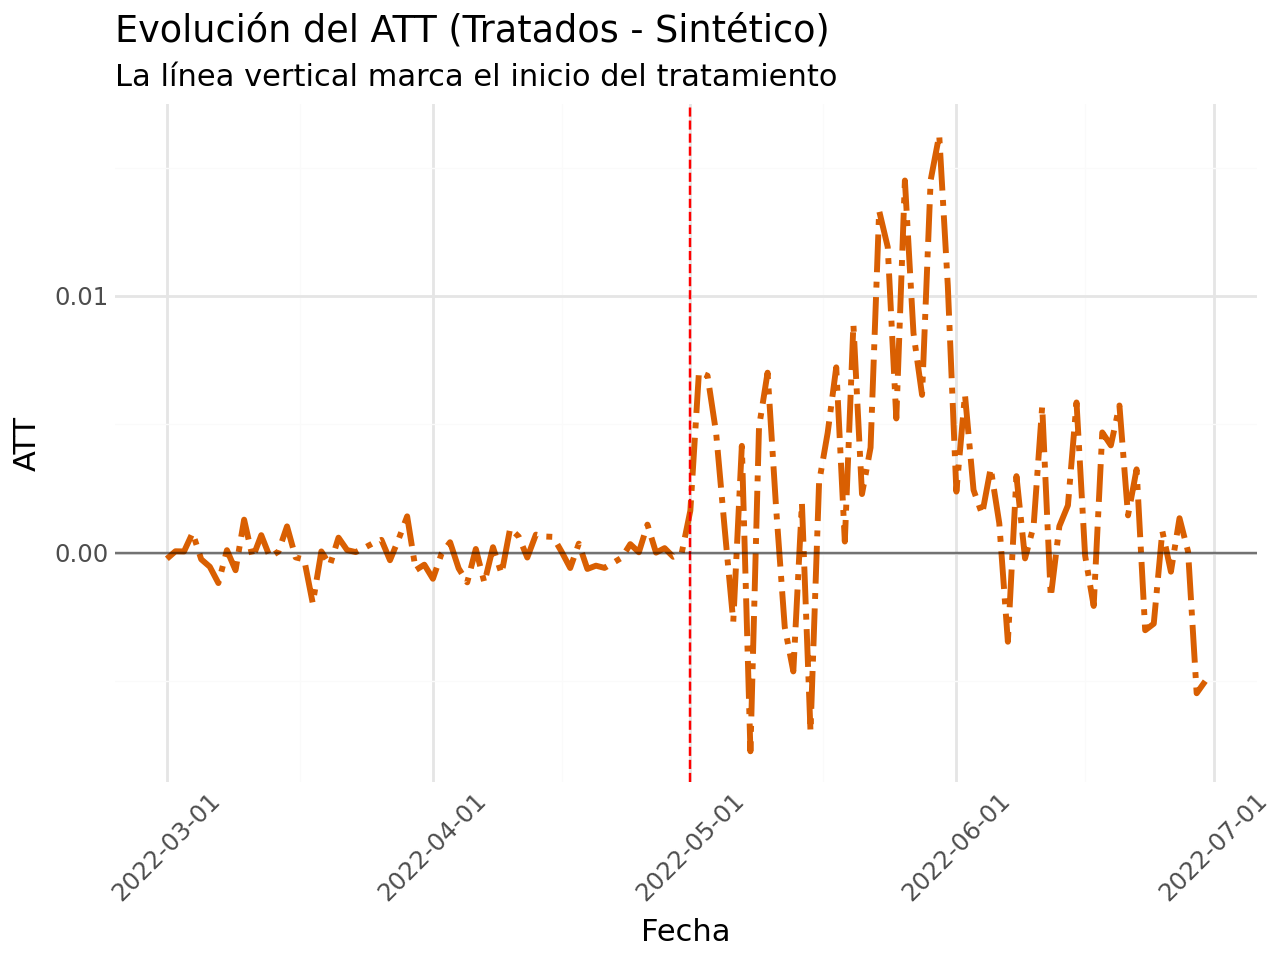

In [80]:
from plotnine import *

# Calculamos el ATT para cada fecha
df_plot = df_plot.with_columns(
    ATT = pl.col("treated_avg") - pl.col("synthetic")
)

# Creamos el gráfico
(
    ggplot(df_plot, aes(x="date", y="ATT"))
    + geom_line(linetype="dashdot", color="#d95f02", size=1.2)
    + geom_vline(xintercept=pd.to_datetime(tr_period), linetype="dashed", color="red", show_legend=True)
    + geom_hline(yintercept=0, linetype="solid", color="black", alpha=0.5)
    + labs(
        title="Evolución del ATT (Tratados - Sintético)",
        subtitle="La línea vertical marca el inicio del tratamiento",
        y="ATT",
        x="Fecha"
    )
    + theme_minimal()
    + theme(axis_text_x=element_text(rotation=45))
)

## Canonical Synthetic Control


In [81]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
import cvxpy as cp

class SyntheticControl(BaseEstimator, RegressorMixin):
    def __init__(self,):
        pass

    def fit(self, y_pre_co, y_pre_tr):
        y_pre_co, y_pre_tr = check_X_y(y_pre_co, y_pre_tr)

        w = cp.Variable(y_pre_co.shape[1])

        objective = cp.Minimize(cp.sum_squares(y_pre_co@w - y_pre_tr))
        constraints = [cp.sum(w) == 1, w >= 0]

        problem = cp.Problem(objective, constraints)

        self.loss_ = problem.solve(verbose=False)
        self.w_ = w.value

        self.is_fitted_ = True
        return self


    def predict(self, y_co):
        check_is_fitted(self)
        y_co = check_array(y_co)

        return y_co @ self.w_


In [82]:
model = SyntheticControl()
model.fit(y_pre_co.drop("date").to_pandas(), y_pre_tr.drop("date").to_pandas().mean(axis=1))

SyntheticControl()

In [83]:
# extrac the weights

model.w_.round(3)


array([ 0.046,  0.076,  0.089,  0.123, -0.   , -0.   , -0.   , -0.   ,
        0.008, -0.   ,  0.074,  0.037, -0.   ,  0.061, -0.   , -0.   ,
        0.083, -0.   ,  0.   ,  0.067, -0.   ,  0.   ,  0.   ,  0.   ,
       -0.   ,  0.086,  0.092,  0.088, -0.   , -0.   , -0.   , -0.   ,
        0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   ,
       -0.   ,  0.   ,  0.061, -0.   ,  0.01 , -0.   , -0.   ])

In [84]:
# same as y0_tr_hat = model.predict(y_post_co)
y0_tr_hat = y_post_co.drop("date").to_pandas().dot(weights_lr)
y0_tr_hat[:]

0     0.013356
1     0.018682
2     0.016760
3     0.014669
4     0.012445
        ...   
56    0.019992
57    0.029849
58    0.024227
59    0.028336
60    0.029129
Length: 61, dtype: float64

In [85]:
df_plot = pl.DataFrame({
    "date": df_controls_all["date"],
    "synthetic": model.predict(df_controls_all.drop("date").to_pandas()),
    "treated_avg": treated_avg
})


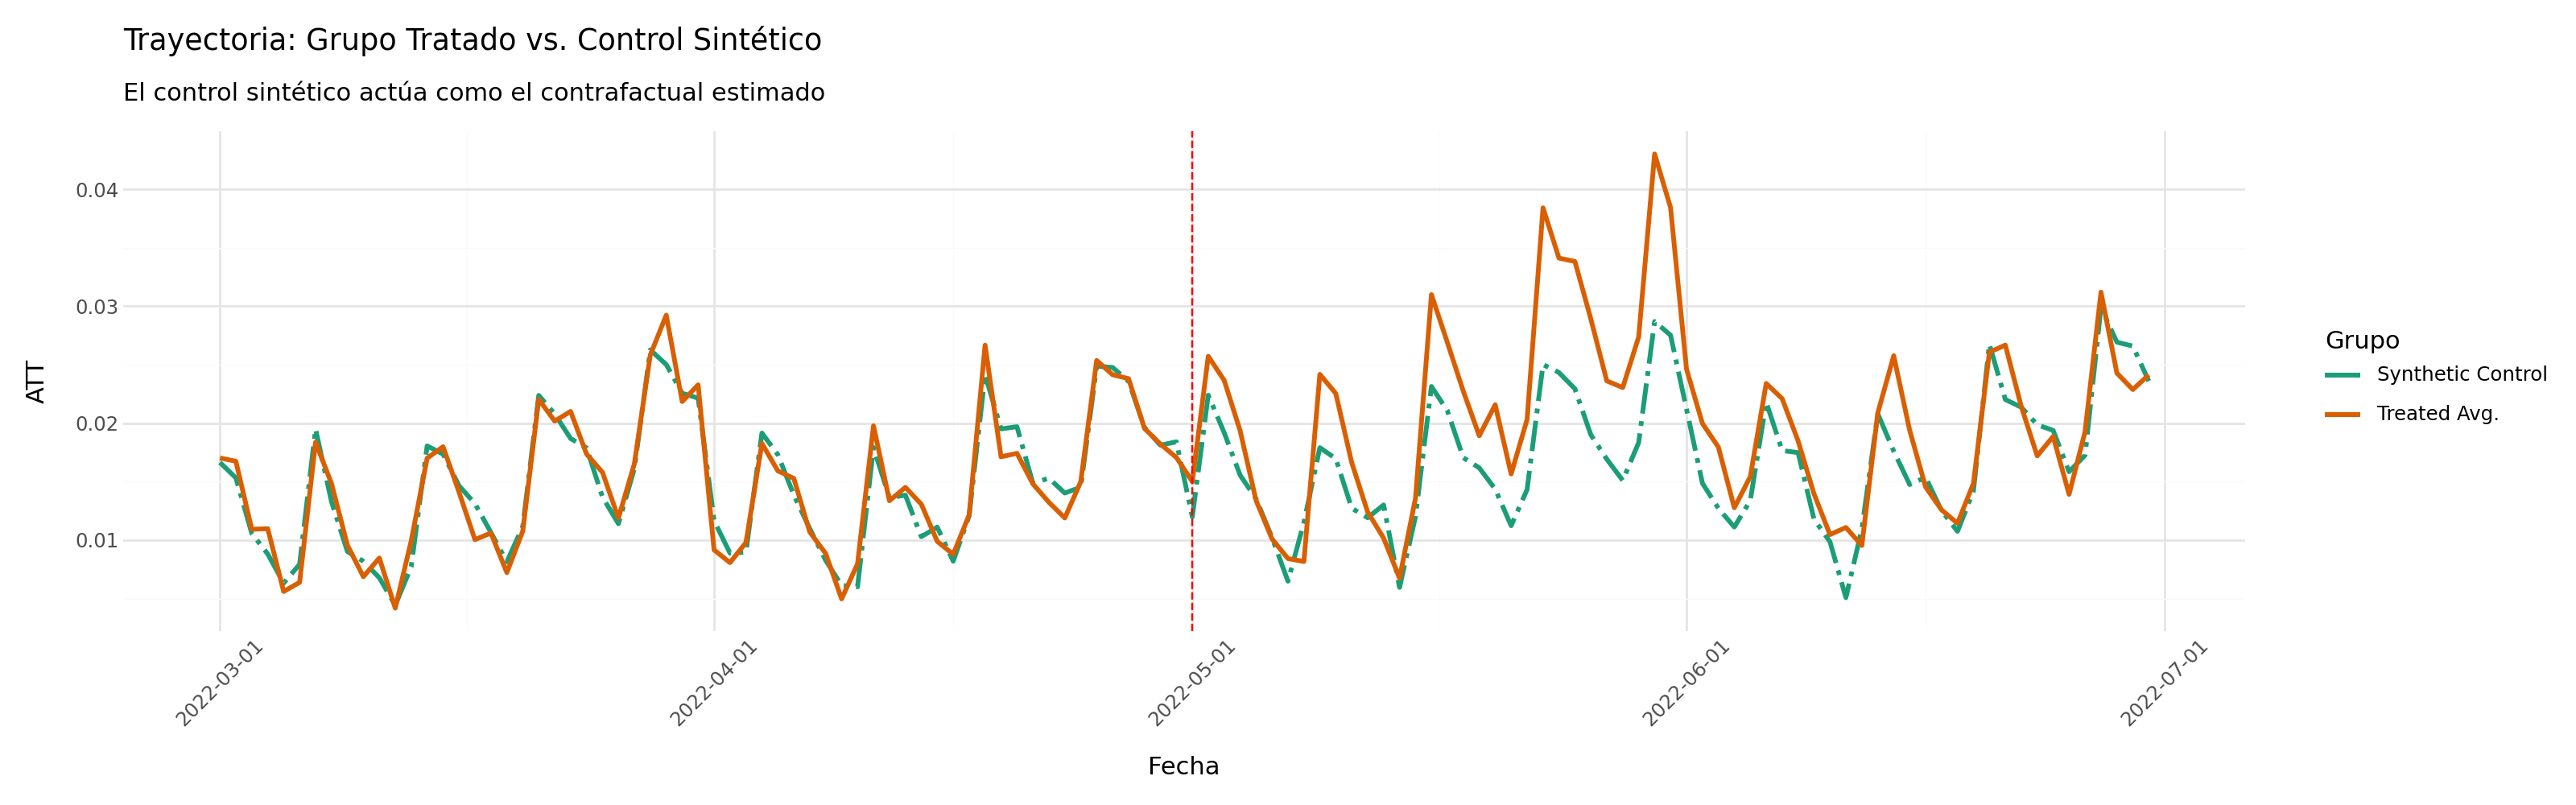

In [86]:
from plotnine import *

(
    ggplot(df_plot, aes(x="date"))
    + geom_line(aes(y="synthetic", color="'Synthetic Control'"), linetype="dashdot", size=1.2)
    + geom_line(aes(y="treated_avg", color="'Treated Avg.'"), size=1.2)
    + geom_vline(xintercept=pd.to_datetime(tr_period), linetype="dashed", color="red")
    + scale_color_manual(
        name="Grupo",
        values={"Synthetic Control": "#1b9e77", "Treated Avg.": "#d95f02"}
    )
    + labs(
        title="Trayectoria: Grupo Tratado vs. Control Sintético",
        subtitle="El control sintético actúa como el contrafactual estimado",
        y="ATT",
        x="Fecha"
    )
    + theme_minimal()
    + theme(
        axis_text_x=element_text(rotation=45),
        figure_size=(16, 5)  # <-- Aquí defines el largo (ancho) y alto del plot
    )
)


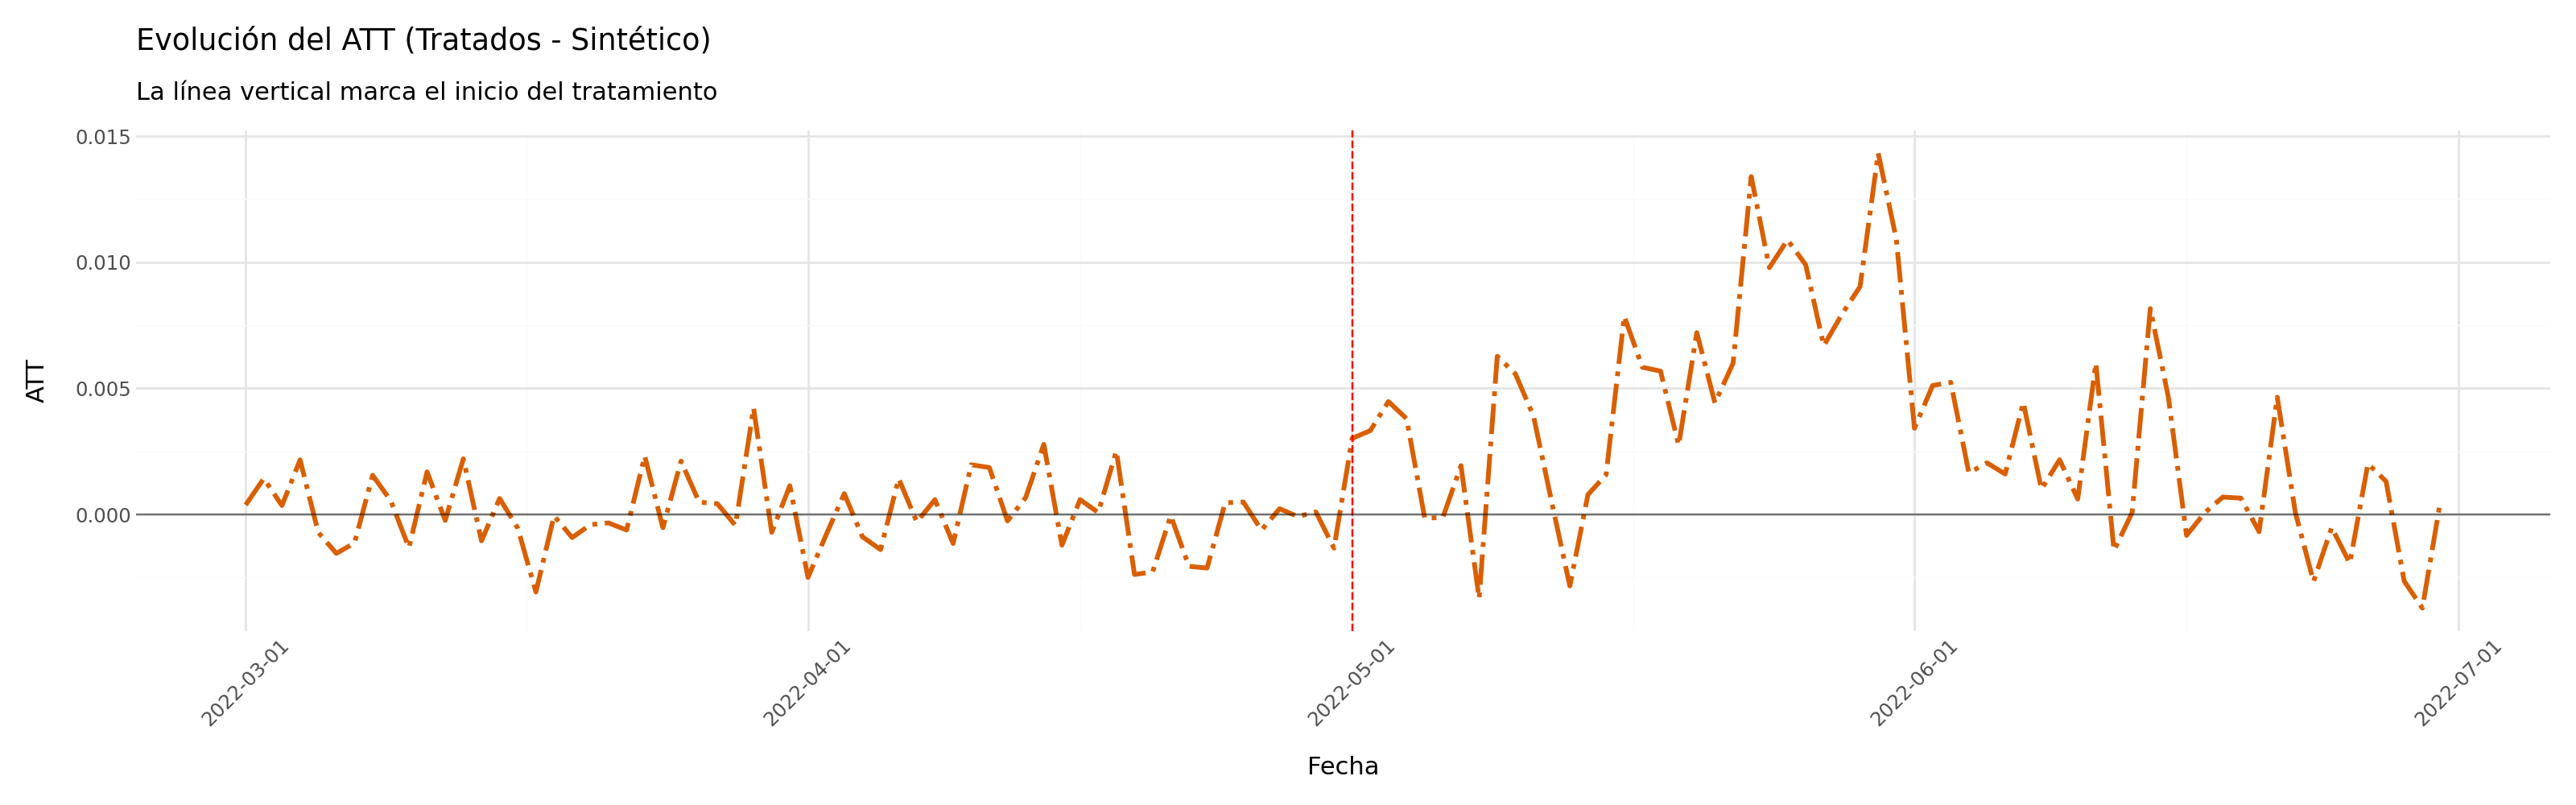

In [87]:
## ATT plotnine

df_plot = df_plot.with_columns(
    ATT = pl.col("treated_avg") - pl.col("synthetic")
)

(
    ggplot(df_plot, aes(x="date", y="ATT"))
    + geom_line(linetype="dashdot", color="#d95f02", size=1.2)
    + geom_vline(xintercept=pd.to_datetime(tr_period), linetype="dashed", color="red", show_legend=True)
    + geom_hline(yintercept=0, linetype="solid", color="black", alpha=0.5)
    + labs(
        title="Evolución del ATT (Tratados - Sintético)",
        subtitle="La línea vertical marca el inicio del tratamiento",
        y="ATT",
        x="Fecha"
    )
    + theme_minimal()
    + theme(
        axis_text_x=element_text(rotation=45),
        figure_size=(16, 5)  # <-- Aquí defines el largo (ancho) y alto del plot
    )
)

## Synthetic Control with Covariants

In [88]:
df_norm_cov = pl.read_csv("../data/online_mkt_cov.csv").with_columns(
    pl.col("date").str.to_date()
)

df_norm_cov.head()

app_download,population,city,state,date,post,treated,app_download_pct,comp_download_pct
f64,i64,str,str,date,i64,i64,f64,f64
3066.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-01,0,1,0.024733,0.02628
2701.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-02,0,1,0.021789,0.023925
1927.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-03,0,1,0.015545,0.01893
1451.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-04,0,1,0.011705,0.015858
1248.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-05,0,1,0.010067,0.014548


In [89]:
from toolz import partial

reshaper = partial(reshape_sc_data,
                   df=df_norm_cov,
                   geo_col="city",
                   time_col="date",
                   tr_geos=treated,
                   tr_start_st=str(tr_period))

y_pre_co, y_pre_tr, y_post_co, y_post_tr = reshaper(
    y_col="app_download_pct"
)

x_pre_co, _, x_post_co, _ = reshaper(y_col="comp_download_pct")

In [90]:
def find_w_given_vs(vs, x_co_list, y_tr_pre):
    # Multiplicamos cada DataFrame por su respectivo peso y sumamos columna a columna
    # Primero, eliminamos la columna "date" y convertimos a pandas
    x_weighted = [
        x.drop("date").to_pandas() * v
        for x, v in zip(x_co_list, vs)
    ]
    # Sumamos los DataFrames ponderados
    X_times_v = sum(x_weighted)
    
    model = SyntheticControl()
    model.fit(X_times_v, y_tr_pre)
    return {"loss": model.loss_, "w": model.w_}

# Ejemplo de uso:
find_w_given_vs(
    [1, 0],
    [y_pre_co, x_pre_co],
    y_pre_tr.drop("date").to_pandas().mean(axis=1)
).get("w").round(3)

array([ 0.046,  0.076,  0.089,  0.123, -0.   , -0.   , -0.   , -0.   ,
        0.008, -0.   ,  0.074,  0.037, -0.   ,  0.061, -0.   , -0.   ,
        0.083, -0.   ,  0.   ,  0.067, -0.   ,  0.   ,  0.   ,  0.   ,
       -0.   ,  0.086,  0.092,  0.088, -0.   , -0.   , -0.   , -0.   ,
        0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   ,
       -0.   ,  0.   ,  0.061, -0.   ,  0.01 , -0.   , -0.   ])

In [91]:
from scipy.optimize import minimize

def v_loss(vs):
    return find_w_given_vs(vs,[y_pre_co, x_pre_co],
                            y_pre_tr.drop("date").to_pandas().mean(axis=1)).get("loss")

v_solution = minimize(v_loss, [0, 0], method='L-BFGS-B')
v_solution.x


array([1.80162591, 0.00311653])

In [92]:
w_cov = find_w_given_vs(v_solution.x,
    [y_pre_co, x_pre_co],
    y_pre_tr.drop("date").to_pandas().mean(axis=1)).get("w").round(3)
w_cov

array([ 0.   ,  0.086,  0.147,  0.051, -0.   , -0.   ,  0.   ,  0.007,
        0.031, -0.   ,  0.01 ,  0.   ,  0.16 ,  0.009,  0.   , -0.   ,
        0.034,  0.   ,  0.   ,  0.023, -0.   , -0.   ,  0.   ,  0.   ,
       -0.   ,  0.169,  0.048,  0.036,  0.035,  0.   ,  0.   , -0.   ,
        0.   , -0.   ,  0.053,  0.   ,  0.084, -0.   ,  0.   , -0.   ,
       -0.   ,  0.   ,  0.016, -0.   , -0.   , -0.   , -0.   ])

In [94]:
# Paso 1: Convertimos los DataFrames a numpy, quitando la columna "date"
y_post_co_np = y_post_co.drop("date").to_numpy()
x_post_co_np = x_post_co.drop("date").to_numpy()

# Paso 2: Multiplicamos cada matriz por su respectivo v
X_times_v = y_post_co_np * v_solution.x[0] + x_post_co_np * v_solution.x[1]

# Paso 3: Producto matricial con los pesos w_cov
y0_hat = X_times_v @ w_cov

att = y_post_tr.drop("date").to_pandas().mean(axis=1) - y0_hat
att

0     0.002829
1     0.003948
2     0.004959
3     0.004268
4     0.000794
        ...   
56    0.002241
57    0.001918
58   -0.002604
59   -0.002976
60    0.000170
Length: 61, dtype: float64

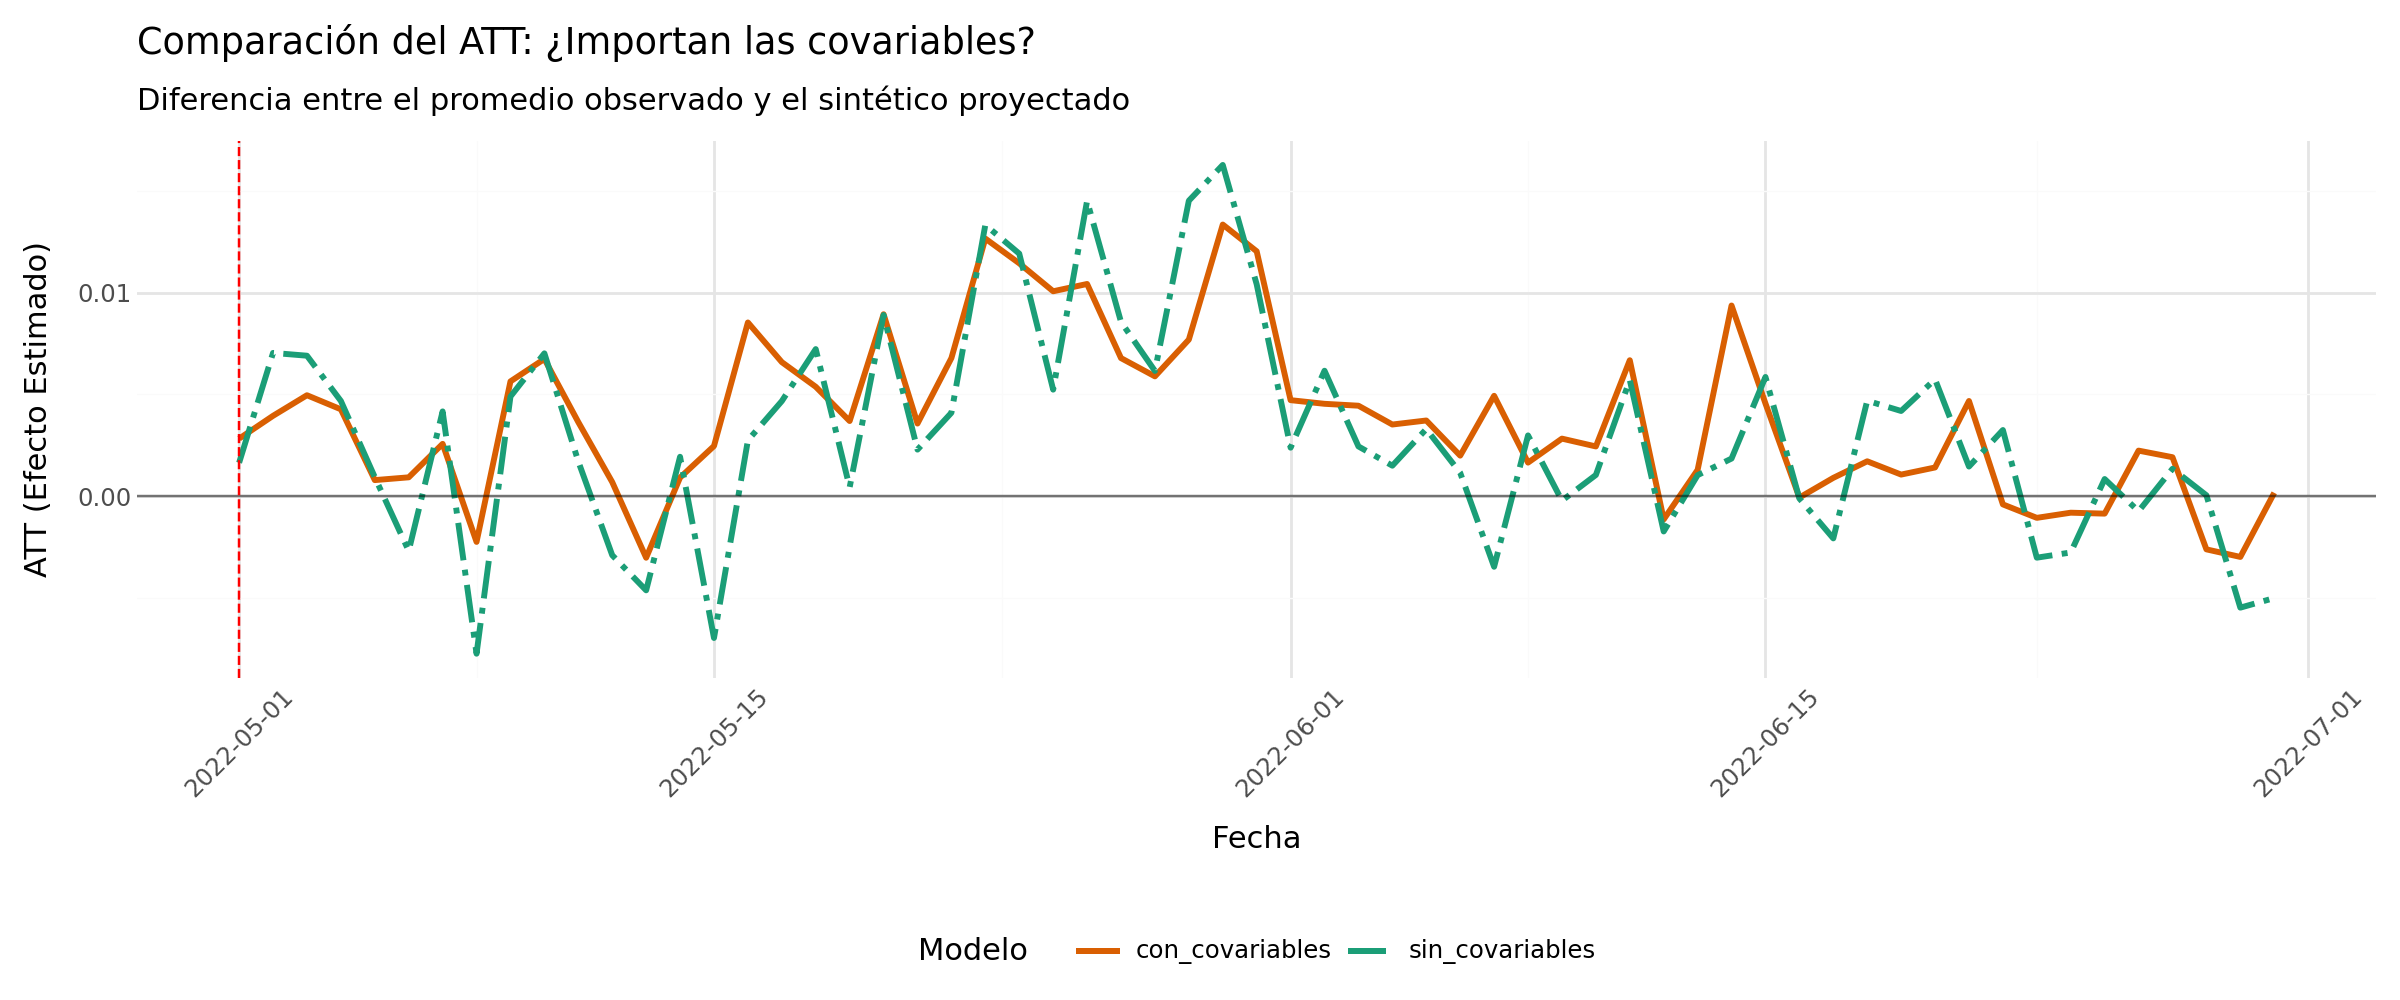

In [97]:
# 1. Preparar los datos del ATT para ambos modelos
# Extraemos el promedio real de los tratados en el periodo post
treated_avg_post = y_post_tr.drop("date").to_pandas().mean(axis=1).values

# Creamos un DataFrame consolidado con Polars
df_att_compare = (
    y_post_tr.select("date")
    .with_columns(
        sin_covariables = treated_avg_post - y0_tr_hat.values,
        con_covariables = treated_avg_post - y0_hat
    )
    # Transformamos a formato largo (tidy) para plotnine
    .unpivot(
        index="date", 
        variable_name="Modelo", 
        value_name="ATT"
    )
)

# 2. Visualización con Plotnine
(
    ggplot(df_att_compare, aes(x="date", y="ATT", color="Modelo", linetype="Modelo"))
    + geom_line(size=1.2)
    + geom_hline(yintercept=0, color="black", alpha=0.5)
    + geom_vline(xintercept=pd.to_datetime(tr_period), linetype="dashed", color="red")
    + scale_color_manual(values={"sin_covariables": "#1b9e77", "con_covariables": "#d95f02"})
    + scale_linetype_manual(values={"sin_covariables": "dashdot", "con_covariables": "solid"})
    + labs(
        title="Comparación del ATT: ¿Importan las covariables?",
        subtitle="Diferencia entre el promedio observado y el sintético proyectado",
        x="Fecha",
        y="ATT (Efecto Estimado)"
    )
    + theme_minimal()
    + theme(
        axis_text_x=element_text(rotation=45),
        figure_size=(12, 5),
        legend_position="bottom"
    )
)

## Debiasing Synthetic Control

In [60]:
import pandas as pd
import numpy as np

def generar_proyeccion(producto, base_demanda, costo_receta, precio_venta, factores_dia, nombre_archivo):
    """
    Genera una proyección de ventas y la guarda en Excel.
    
    Parámetros:
    - producto: Nombre del producto (ej. "Ensalada")
    - base_demanda: Venta promedio diaria base (ej. 3)
    - costo_receta: Costo unitario o por lote (si es por lote, ajustarlo antes)
    - precio_venta: Precio al público
    - factores_dia: Diccionario con multiplicadores por día de la semana (0=Lunes, 6=Domingo)
    - nombre_archivo: Nombre del archivo Excel a guardar (ej. 'ventas_enero.xlsx')
    """
    
    # Configuración de Fechas (Enero 2026)
    fechas = pd.date_range(start='2026-01-01', periods=31)
    np.random.seed(42) # Semilla para resultados consistentes

    data = []
    
    # Traducción de días
    dias_esp = {
        'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
        'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 
        'Sunday': 'Domingo'
    }

    for fecha in fechas:
        dia_semana = fecha.dayofweek # 0=Lunes, ... 6=Domingo
        nombre_dia = fecha.day_name()
        
        # 1. Obtener el factor multiplicador del día
        # Si el día no está en el diccionario, asume 0 (cerrado)
        multiplicador = factores_dia.get(dia_semana, 0.0)
        
        if multiplicador == 0:
            ventas = 0
        else:
            # 2. Calcular Ventas con Ruido y Tendencia
            # Ruido: Variación aleatoria del +/- 10%
            ruido = np.random.normal(1, 0.1)
            
            # Tendencia: Crece ligeramente conforme avanza el mes (efecto dieta enero)
            tendencia = fecha.day * 0.08 
            
            ventas_calculadas = (base_demanda * multiplicador * ruido) + tendencia
            ventas = int(round(ventas_calculadas))
            
            if ventas < 0: ventas = 0

        # 3. Cálculos Financieros
        ingresos = ventas * precio_venta
        costos = ventas * costo_receta
        utilidad = ingresos - costos
        
        data.append([dias_esp[nombre_dia], fecha.day, ventas, ingresos, costos, utilidad])

    # Crear DataFrame
    columnas = ['DÍA', 'FECHA', 'VENTAS (#)', 'INGRESOS ($)', 'COSTOS MP ($)', 'UTILIDAD ($)']
    df = pd.DataFrame(data, columns=columnas)
    
    # Guardar a Excel
    df.to_excel(nombre_archivo, index=False)
    print(f"✅ Proyección generada para '{producto}' y guardada en: {nombre_archivo}")
    
    return df

# ==========================================
# --- ZONA DE PERSONALIZACIÓN (EDITA AQUÍ) ---
# ==========================================

# 1. Define qué tan fuerte es cada día respecto a la base
# 1.0 = Venta normal
# 1.5 = Venta alta (50% más)
# 0.5 = Venta baja (mitad)
# 0.0 = Cerrado
mis_factores = {
    0: 2.0,  # Lunes (Normal)
    1: 1.6,  # Martes
    2: 1.0,  # Miércoles
    3: 1.5,  # Jueves (Sube un poco)
    4: 1.2,  # Viernes (Más alto)
    5: 1.8,  # Sábado (El día más fuerte, como pediste)
    6: 0.0   # Domingo (Cerrado)
}

# 2. Ejecuta la función con tus datos
df_resultado = generar_proyeccion(
    producto="Ensalada de Espinaca",
    base_demanda=4,       # Tu base baja solicitada
    costo_receta=28.98,   # Costo unitario
    precio_venta=115,  # Precio de venta
    factores_dia=mis_factores,
    nombre_archivo='pronostico_ensalada.xlsx'
)

# 3. Ver resultado en pantalla
print(df_resultado.head(10).to_string(index=False))

✅ Proyección generada para 'Ensalada de Espinaca' y guardada en: pronostico_ensalada.xlsx
      DÍA  FECHA  VENTAS (#)  INGRESOS ($)  COSTOS MP ($)  UTILIDAD ($)
   Jueves      1           6           690         173.88        516.12
  Viernes      2           5           575         144.90        430.10
   Sábado      3           8           920         231.84        688.16
  Domingo      4           0             0           0.00          0.00
    Lunes      5          10          1150         289.80        860.20
   Martes      6           7           805         202.86        602.14
Miércoles      7           4           460         115.92        344.08
   Jueves      8           8           920         231.84        688.16
  Viernes      9           6           690         173.88        516.12
   Sábado     10           8           920         231.84        688.16
